In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict
import json
import os

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries loaded successfully
NumPy version: 1.26.4
Pandas version: 2.3.2


In [2]:

# Analysis Plan:
# 1. Implement helper functions for number theory (primality, squarefree testing, omega)
# 2. Implement two Dirichlet characters:
# a) χ₄ mod 5 (correct): χ(1)=1, χ(2)=-1, χ(3)=-1, χ(4)=1, χ(5)=0
# b) χ_4 mod 4 (artifact): χ(1)=1, χ(2)=0, χ(3)=-1, χ(4)=0
# 3. Generate coefficients a_n for both L-functions up to N=10^5
# 4. Calculate density of negative coefficients (a_n = -1) for composite squarefree numbers
# 5. Compute time series R_comp(t) for t in [1000, 10000]
# 6. Calculate mean R_comp for both functions
# 7. Test correlation between negative coefficient density and mean R_comp

print("=== ANALYSIS PLAN ===")
print("Step 1: Implement helper functions for number theory")
print("Step 2: Implement χ₄ mod 5 (correct character)")
print("Step 3: Implement χ_4 mod 4 (artifact character)")
print("Step 4: Generate coefficients up to N=10^5")
print("Step 5: Calculate density of a_n=-1 for composite squarefree numbers")
print("Step 6: Compute R_comp(t) time series for t in [1000, 10000]")
print("Step 7: Calculate mean R_comp for both functions")
print("Step 8: Test correlation between negative coefficient density and mean R_comp")


=== ANALYSIS PLAN ===
Step 1: Implement helper functions for number theory
Step 2: Implement χ₄ mod 5 (correct character)
Step 3: Implement χ_4 mod 4 (artifact character)
Step 4: Generate coefficients up to N=10^5
Step 5: Calculate density of a_n=-1 for composite squarefree numbers
Step 6: Compute R_comp(t) time series for t in [1000, 10000]
Step 7: Calculate mean R_comp for both functions
Step 8: Test correlation between negative coefficient density and mean R_comp


In [3]:

# Step 1: Helper functions for number theory

def sieve_of_eratosthenes(n):
 """Generate all primes up to n using Sieve of Eratosthenes"""
 if n < 2:
 return []
 is_prime = np.ones(n + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 for i in range(2, int(n**0.5) + 1):
 if is_prime[i]:
 is_prime[i*i:n+1:i] = False
 return np.where(is_prime)[0]

def compute_squarefree_mask(n_max):
 """Compute boolean array where squarefree_mask[n] = True if n is squarefree"""
 squarefree_mask = np.ones(n_max + 1, dtype=bool)
 squarefree_mask[0] = False
 
 primes = sieve_of_eratosthenes(int(n_max**0.5) + 1)
 for p in primes:
 p2 = p * p
 squarefree_mask[p2::p2] = False
 
 return squarefree_mask

def compute_omega(n_max):
 """Compute ω(n) = number of distinct prime factors for all n <= n_max"""
 omega = np.zeros(n_max + 1, dtype=int)
 primes = sieve_of_eratosthenes(n_max)
 
 for p in primes:
 omega[p::p] += 1
 
 return omega

# Test the functions
N_test = 20
primes_test = sieve_of_eratosthenes(N_test)
squarefree_test = compute_squarefree_mask(N_test)
omega_test = compute_omega(N_test)

print(f"Primes up to {N_test}: {primes_test}")
print(f"Squarefree numbers: {np.where(squarefree_test)[0]}")
print(f"ω(n) for n=1 to {N_test}: {omega_test}")


Primes up to 20: [ 2 3 5 7 11 13 17 19]
Squarefree numbers: [ 1 2 3 5 6 7 10 11 13 14 15 17 19]
ω(n) for n=1 to 20: [0 0 1 1 1 1 2 1 1 1 2 1 2 1 2 2 1 1 2 1 2]


In [4]:

# Step 2 & 3: Implement Dirichlet characters

def chi_4_mod5(n):
 """
 Real primitive character modulo 5 (correct χ₄)
 χ(1) = 1, χ(2) = -1, χ(3) = -1, χ(4) = 1, χ(0 mod 5) = 0
 """
 n_mod = n % 5
 if n_mod == 0:
 return 0
 elif n_mod == 1:
 return 1
 elif n_mod == 2:
 return -1
 elif n_mod == 3:
 return -1
 elif n_mod == 4:
 return 1

def chi_4_mod4(n):
 """
 Real primitive character modulo 4 (artifact character)
 χ(1) = 1, χ(2) = 0, χ(3) = -1, χ(0 mod 4) = 0
 """
 n_mod = n % 4
 if n_mod == 0:
 return 0
 elif n_mod == 1:
 return 1
 elif n_mod == 2:
 return 0
 elif n_mod == 3:
 return -1

# Test the characters
print("=== Character χ₄ mod 5 (correct) ===")
for n in range(1, 21):
 print(f"χ₄({n:2d}) = {chi_4_mod5(n):2d}", end=" ")
 if n % 5 == 0:
 print()

print("\n=== Character χ_4 mod 4 (artifact) ===")
for n in range(1, 21):
 print(f"χ_4({n:2d}) = {chi_4_mod4(n):2d}", end=" ")
 if n % 4 == 0:
 print()


=== Character χ₄ mod 5 (correct) ===
χ₄( 1) = 1 χ₄( 2) = -1 χ₄( 3) = -1 χ₄( 4) = 1 χ₄( 5) = 0 
χ₄( 6) = 1 χ₄( 7) = -1 χ₄( 8) = -1 χ₄( 9) = 1 χ₄(10) = 0 
χ₄(11) = 1 χ₄(12) = -1 χ₄(13) = -1 χ₄(14) = 1 χ₄(15) = 0 
χ₄(16) = 1 χ₄(17) = -1 χ₄(18) = -1 χ₄(19) = 1 χ₄(20) = 0 

=== Character χ_4 mod 4 (artifact) ===
χ_4( 1) = 1 χ_4( 2) = 0 χ_4( 3) = -1 χ_4( 4) = 0 
χ_4( 5) = 1 χ_4( 6) = 0 χ_4( 7) = -1 χ_4( 8) = 0 
χ_4( 9) = 1 χ_4(10) = 0 χ_4(11) = -1 χ_4(12) = 0 
χ_4(13) = 1 χ_4(14) = 0 χ_4(15) = -1 χ_4(16) = 0 
χ_4(17) = 1 χ_4(18) = 0 χ_4(19) = -1 χ_4(20) = 0 


In [5]:

# Step 4: Generate coefficients for both L-functions up to N=10^5

N = 100000
print(f"Generating coefficients up to N={N}")

# Precompute number theory data
squarefree_mask = compute_squarefree_mask(N)
omega = compute_omega(N)
primes = sieve_of_eratosthenes(N)
is_prime = np.zeros(N + 1, dtype=bool)
is_prime[primes] = True

# Generate coefficients for L(s, χ₄) mod 5 (correct)
# For multiplicative L-functions, a_n = χ(n) for all n (including non-squarefree)
a_chi4_mod5 = np.array([chi_4_mod5(n) for n in range(N + 1)])

# Generate coefficients for L(s, χ_4) mod 4 (artifact)
a_chi4_mod4 = np.array([chi_4_mod4(n) for n in range(N + 1)])

print(f"Coefficients generated for both characters")
print(f"χ₄ mod 5: {np.sum(a_chi4_mod5 != 0)} non-zero coefficients")
print(f"χ_4 mod 4: {np.sum(a_chi4_mod4 != 0)} non-zero coefficients")


Generating coefficients up to N=100000
Coefficients generated for both characters
χ₄ mod 5: 80000 non-zero coefficients
χ_4 mod 4: 50000 non-zero coefficients


In [6]:

# Step 5: Calculate density of negative coefficients (a_n = -1) for composite squarefree numbers

# Identify composite squarefree numbers
is_composite = ~is_prime
is_composite[0] = False # 0 is not composite
is_composite[1] = False # 1 is not composite

composite_squarefree_mask = is_composite & squarefree_mask
composite_squarefree_indices = np.where(composite_squarefree_mask)[0]

print(f"Total composite squarefree numbers up to N={N}: {len(composite_squarefree_indices)}")
print(f"First 20 composite squarefree numbers: {composite_squarefree_indices[:20]}")

# Calculate density of a_n = -1 for composite squarefree numbers
# For χ₄ mod 5
negative_count_mod5 = np.sum(a_chi4_mod5[composite_squarefree_indices] == -1)
total_nonzero_mod5 = np.sum(a_chi4_mod5[composite_squarefree_indices] != 0)
density_negative_mod5 = negative_count_mod5 / total_nonzero_mod5 if total_nonzero_mod5 > 0 else 0

# For χ_4 mod 4
negative_count_mod4 = np.sum(a_chi4_mod4[composite_squarefree_indices] == -1)
total_nonzero_mod4 = np.sum(a_chi4_mod4[composite_squarefree_indices] != 0)
density_negative_mod4 = negative_count_mod4 / total_nonzero_mod4 if total_nonzero_mod4 > 0 else 0

print("\n=== Density of a_n = -1 for Composite Squarefree Numbers ===")
print(f"χ₄ mod 5 (correct):")
print(f" Negative coefficients: {negative_count_mod5}")
print(f" Non-zero coefficients: {total_nonzero_mod5}")
print(f" Density: {density_negative_mod5:.6f}")

print(f"\nχ_4 mod 4 (artifact):")
print(f" Negative coefficients: {negative_count_mod4}")
print(f" Non-zero coefficients: {total_nonzero_mod4}")
print(f" Density: {density_negative_mod4:.6f}")

print(f"\nDifference in density: {abs(density_negative_mod5 - density_negative_mod4):.6f}")


Total composite squarefree numbers up to N=100000: 51201
First 20 composite squarefree numbers: [ 6 10 14 15 21 22 26 30 33 34 35 38 39 42 46 51 55 57 58 62]

=== Density of a_n = -1 for Composite Squarefree Numbers ===
χ₄ mod 5 (correct):
 Negative coefficients: 20516
 Non-zero coefficients: 41068
 Density: 0.499562

χ_4 mod 4 (artifact):
 Negative coefficients: 15459
 Non-zero coefficients: 30935
 Density: 0.499725

Difference in density: 0.000164


In [7]:

# Let me verify this more carefully - the density of -1 coefficients appears nearly identical
# Let's look at the actual distribution of coefficients for composite squarefree numbers

print("=== Detailed Coefficient Distribution for Composite Squarefree Numbers ===")

# For χ₄ mod 5
coeff_values_mod5 = a_chi4_mod5[composite_squarefree_indices]
unique_mod5, counts_mod5 = np.unique(coeff_values_mod5, return_counts=True)
print("\nχ₄ mod 5 (correct):")
for val, count in zip(unique_mod5, counts_mod5):
 pct = 100 * count / len(composite_squarefree_indices)
 print(f" a_n = {val:2d}: {count:6d} ({pct:5.2f}%)")

# For χ_4 mod 4
coeff_values_mod4 = a_chi4_mod4[composite_squarefree_indices]
unique_mod4, counts_mod4 = np.unique(coeff_values_mod4, return_counts=True)
print("\nχ_4 mod 4 (artifact):")
for val, count in zip(unique_mod4, counts_mod4):
 pct = 100 * count / len(composite_squarefree_indices)
 print(f" a_n = {val:2d}: {count:6d} ({pct:5.2f}%)")

# Look at a few examples
print("\n=== Sample Composite Squarefree Numbers ===")
print("n ω(n) χ₄(mod5) χ_4(mod4)")
for i in range(min(30, len(composite_squarefree_indices))):
 n = composite_squarefree_indices[i]
 print(f"{n:5d} {omega[n]:2d} {a_chi4_mod5[n]:2d} {a_chi4_mod4[n]:2d}")


=== Detailed Coefficient Distribution for Composite Squarefree Numbers ===

χ₄ mod 5 (correct):
 a_n = -1: 20516 (40.07%)
 a_n = 0: 10133 (19.79%)
 a_n = 1: 20552 (40.14%)

χ_4 mod 4 (artifact):
 a_n = -1: 15459 (30.19%)
 a_n = 0: 20266 (39.58%)
 a_n = 1: 15476 (30.23%)

=== Sample Composite Squarefree Numbers ===
n ω(n) χ₄(mod5) χ_4(mod4)
 6 2 1 0
 10 2 0 0
 14 2 1 0
 15 2 0 -1
 21 2 1 1
 22 2 -1 0
 26 2 1 0
 30 3 0 0
 33 2 -1 1
 34 2 1 0
 35 2 0 -1
 38 2 -1 0
 39 2 1 -1
 42 3 -1 0
 46 2 1 0
 51 2 1 -1
 55 2 0 -1
 57 2 -1 1
 58 2 -1 0
 62 2 -1 0
 65 2 0 1
 66 3 1 0
 69 2 1 1
 70 3 0 0
 74 2 1 0
 77 2 -1 1
 78 3 -1 0
 82 2 -1 0
 85 2 0 1
 86 2 1 0


In [8]:

# I see the issue - for χ_4 mod 4, there are significantly more zeros (39.58% vs 19.79%)
# So we need to recalculate the density considering only non-zero coefficients vs all composite squarefree

print("=== Recalculated Densities ===")
print("\nDensity of a_n = -1 among NON-ZERO coefficients:")
print(f"χ₄ mod 5: {negative_count_mod5}/{total_nonzero_mod5} = {density_negative_mod5:.6f}")
print(f"χ_4 mod 4: {negative_count_mod4}/{total_nonzero_mod4} = {density_negative_mod4:.6f}")

print("\nDensity of a_n = -1 among ALL composite squarefree numbers:")
density_negative_all_mod5 = negative_count_mod5 / len(composite_squarefree_indices)
density_negative_all_mod4 = negative_count_mod4 / len(composite_squarefree_indices)
print(f"χ₄ mod 5: {negative_count_mod5}/{len(composite_squarefree_indices)} = {density_negative_all_mod5:.6f}")
print(f"χ_4 mod 4: {negative_count_mod4}/{len(composite_squarefree_indices)} = {density_negative_all_mod4:.6f}")

print("\nDensity of NON-ZERO coefficients among ALL composite squarefree numbers:")
density_nonzero_mod5 = total_nonzero_mod5 / len(composite_squarefree_indices)
density_nonzero_mod4 = total_nonzero_mod4 / len(composite_squarefree_indices)
print(f"χ₄ mod 5: {total_nonzero_mod5}/{len(composite_squarefree_indices)} = {density_nonzero_mod5:.6f}")
print(f"χ_4 mod 4: {total_nonzero_mod4}/{len(composite_squarefree_indices)} = {density_nonzero_mod4:.6f}")

# Key insight: χ_4 mod 4 has almost TWICE as many zeros as χ₄ mod 5
print(f"\nKey finding: χ_4 mod 4 has {density_nonzero_mod4/density_nonzero_mod5:.3f}x as many non-zero coefficients as χ₄ mod 5")


=== Recalculated Densities ===

Density of a_n = -1 among NON-ZERO coefficients:
χ₄ mod 5: 20516/41068 = 0.499562
χ_4 mod 4: 15459/30935 = 0.499725

Density of a_n = -1 among ALL composite squarefree numbers:
χ₄ mod 5: 20516/51201 = 0.400695
χ_4 mod 4: 15459/51201 = 0.301928

Density of NON-ZERO coefficients among ALL composite squarefree numbers:
χ₄ mod 5: 41068/51201 = 0.802094
χ_4 mod 4: 30935/51201 = 0.604187

Key finding: χ_4 mod 4 has 0.753x as many non-zero coefficients as χ₄ mod 5


In [9]:

# Step 6: Compute R_comp(t) time series for t in [1000, 10000]
# R_comp is the mean resultant length of composite squarefree terms

def compute_partial_sum(a_n, t, N):
 """
 Compute partial sum D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 Returns complex value
 """
 n_values = np.arange(1, N + 1)
 exponents = -0.5 - 1j * t
 weights = n_values ** exponents
 return np.sum(a_n[1:N+1] * weights)

def compute_R_comp_single_t(a_n, t, N, composite_squarefree_mask, squarefree_mask, omega):
 """
 Compute R_comp(t) for a single value of t
 R_comp = mean resultant length of composite squarefree terms
 """
 # Get indices of composite squarefree numbers up to N
 comp_sf_indices = np.where(composite_squarefree_mask[:N+1])[0]
 
 if len(comp_sf_indices) == 0:
 return np.nan
 
 # Compute complex phases for composite squarefree terms
 # Phase for each term: a_n / n^(1/2 + it)
 n_values = comp_sf_indices.astype(float)
 phases = -0.5 - 1j * t
 weights = n_values ** phases
 
 # Get coefficients for these terms
 a_comp = a_n[comp_sf_indices]
 
 # Filter out zero coefficients
 nonzero_mask = (a_comp != 0)
 if np.sum(nonzero_mask) == 0:
 return np.nan
 
 # Compute complex contributions
 complex_terms = a_comp[nonzero_mask] * weights[nonzero_mask]
 
 # Mean resultant length = |mean of unit vectors|
 # First normalize to unit vectors
 unit_vectors = complex_terms / np.abs(complex_terms)
 
 # Mean resultant length
 mean_vector = np.mean(unit_vectors)
 R_comp = np.abs(mean_vector)
 
 return R_comp

# Test with a single value of t
t_test = 1000.0
R_comp_test_mod5 = compute_R_comp_single_t(a_chi4_mod5, t_test, N, composite_squarefree_mask, 
 squarefree_mask, omega)
R_comp_test_mod4 = compute_R_comp_single_t(a_chi4_mod4, t_test, N, composite_squarefree_mask,
 squarefree_mask, omega)

print(f"Test R_comp at t={t_test}:")
print(f" χ₄ mod 5: {R_comp_test_mod5:.6f}")
print(f" χ_4 mod 4: {R_comp_test_mod4:.6f}")


Test R_comp at t=1000.0:
 χ₄ mod 5: 0.001404
 χ_4 mod 4: 0.004056


In [10]:

# Interesting! χ_4 mod 4 shows higher R_comp at this test point
# Now compute the full time series

# Use a sample of t values to make computation feasible
# Sample uniformly from [1000, 10000] with spacing appropriate for analysis
t_min = 1000
t_max = 10000
n_samples = 500 # Sample 500 points for computational efficiency

t_values = np.linspace(t_min, t_max, n_samples)

print(f"Computing R_comp time series for {n_samples} values of t in [{t_min}, {t_max}]")
print("This may take a few minutes...")

R_comp_mod5 = []
R_comp_mod4 = []

# Compute for every 10th point to show progress
for i, t in enumerate(t_values):
 if i % 50 == 0:
 print(f"Progress: {i}/{n_samples} ({100*i/n_samples:.1f}%)")
 
 R_mod5 = compute_R_comp_single_t(a_chi4_mod5, t, N, composite_squarefree_mask,
 squarefree_mask, omega)
 R_mod4 = compute_R_comp_single_t(a_chi4_mod4, t, N, composite_squarefree_mask,
 squarefree_mask, omega)
 
 R_comp_mod5.append(R_mod5)
 R_comp_mod4.append(R_mod4)

R_comp_mod5 = np.array(R_comp_mod5)
R_comp_mod4 = np.array(R_comp_mod4)

print(f"\nComputation complete!")
print(f"χ₄ mod 5: {len(R_comp_mod5)} values computed")
print(f"χ_4 mod 4: {len(R_comp_mod4)} values computed")


Computing R_comp time series for 500 values of t in [1000, 10000]
This may take a few minutes...
Progress: 0/500 (0.0%)


Progress: 50/500 (10.0%)


Progress: 100/500 (20.0%)


Progress: 150/500 (30.0%)


Progress: 200/500 (40.0%)


...

Progress: 300/500 (60.0%)


Progress: 350/500 (70.0%)


Progress: 400/500 (80.0%)


Progress: 450/500 (90.0%)



Computation complete!
χ₄ mod 5: 500 values computed
χ_4 mod 4: 500 values computed


In [11]:

# Step 7: Calculate mean R_comp for both functions

mean_R_comp_mod5 = np.mean(R_comp_mod5)
mean_R_comp_mod4 = np.mean(R_comp_mod4)
std_R_comp_mod5 = np.std(R_comp_mod5)
std_R_comp_mod4 = np.std(R_comp_mod4)

print("=== Mean R_comp Statistics ===")
print(f"\nχ₄ mod 5 (correct):")
print(f" Mean R_comp: {mean_R_comp_mod5:.6f}")
print(f" Std R_comp: {std_R_comp_mod5:.6f}")
print(f" Min R_comp: {np.min(R_comp_mod5):.6f}")
print(f" Max R_comp: {np.max(R_comp_mod5):.6f}")

print(f"\nχ_4 mod 4 (artifact):")
print(f" Mean R_comp: {mean_R_comp_mod4:.6f}")
print(f" Std R_comp: {std_R_comp_mod4:.6f}")
print(f" Min R_comp: {np.min(R_comp_mod4):.6f}")
print(f" Max R_comp: {np.max(R_comp_mod4):.6f}")

print(f"\nDifference in mean R_comp: {mean_R_comp_mod4 - mean_R_comp_mod5:.6f}")
print(f"Ratio (mod 4 / mod 5): {mean_R_comp_mod4 / mean_R_comp_mod5:.3f}x")


=== Mean R_comp Statistics ===

χ₄ mod 5 (correct):
 Mean R_comp: 0.002782
 Std R_comp: 0.001558
 Min R_comp: 0.000096
 Max R_comp: 0.010655

χ_4 mod 4 (artifact):
 Mean R_comp: 0.003297
 Std R_comp: 0.001735
 Min R_comp: 0.000214
 Max R_comp: 0.009765

Difference in mean R_comp: 0.000515
Ratio (mod 4 / mod 5): 1.185x


In [12]:

# Step 8: Test correlation between density of negative coefficients and mean R_comp
# We have two data points:
# 1. χ₄ mod 5: density_negative_all = 0.400695, mean_R_comp = 0.002782
# 2. χ_4 mod 4: density_negative_all = 0.301928, mean_R_comp = 0.003297

# Since we only have 2 data points, we'll report the relationship
# But let's also perform a statistical test to see if the means are significantly different

from scipy.stats import ttest_ind, mannwhitneyu

# Perform t-test
t_stat, p_value_ttest = ttest_ind(R_comp_mod5, R_comp_mod4)

# Perform Mann-Whitney U test (non-parametric alternative)
u_stat, p_value_mw = mannwhitneyu(R_comp_mod5, R_comp_mod4, alternative='two-sided')

print("=== Statistical Testing ===")
print(f"\nTwo-sample t-test:")
print(f" t-statistic: {t_stat:.6f}")
print(f" p-value: {p_value_ttest:.6e}")
print(f" Significant at α=0.05: {p_value_ttest < 0.05}")

print(f"\nMann-Whitney U test:")
print(f" U-statistic: {u_stat:.6f}")
print(f" p-value: {p_value_mw:.6e}")
print(f" Significant at α=0.05: {p_value_mw < 0.05}")

# Effect size (Cohen's d)
pooled_std = np.sqrt((std_R_comp_mod5**2 + std_R_comp_mod4**2) / 2)
cohens_d = (mean_R_comp_mod4 - mean_R_comp_mod5) / pooled_std
print(f"\nEffect size (Cohen's d): {cohens_d:.4f}")


=== Statistical Testing ===

Two-sample t-test:
 t-statistic: -4.937262
 p-value: 9.282060e-07
 Significant at α=0.05: True

Mann-Whitney U test:
 U-statistic: 102791.000000
 p-value: 1.154986e-06
 Significant at α=0.05: True

Effect size (Cohen's d): 0.3126


In [13]:

# Now let's examine the relationship between density and R_comp
# However, the hypothesis stated that higher density of a_n=-1 should lead to higher R_comp
# But we observe the OPPOSITE: χ_4 mod 4 has LOWER density of a_n=-1 but HIGHER R_comp!

print("=== Correlation Analysis ===")
print("\nData points:")
print("Character | Density(a_n=-1) | Mean R_comp")
print("-------------|-----------------|------------")
print(f"χ₄ mod 5 | {density_negative_all_mod5:.6f} | {mean_R_comp_mod5:.6f}")
print(f"χ_4 mod 4 | {density_negative_all_mod4:.6f} | {mean_R_comp_mod4:.6f}")

# With only 2 points, correlation is always ±1, but let's show the relationship
x = np.array([density_negative_all_mod5, density_negative_all_mod4])
y = np.array([mean_R_comp_mod5, mean_R_comp_mod4])

correlation = np.corrcoef(x, y)[0, 1]
print(f"\nPearson correlation: {correlation:.6f}")

# Slope of the line
slope = (y[1] - y[0]) / (x[1] - x[0])
print(f"Slope: {slope:.6f}")
print(f"\nInterpretation: For each 0.1 decrease in density of a_n=-1,")
print(f" R_comp increases by {-slope * 0.1:.6f}")

print("\n=== KEY FINDING ===")
print("The hypothesis prediction is INCORRECT!")
print(f"χ_4 mod 4 has LOWER density of a_n=-1 ({density_negative_all_mod4:.4f} vs {density_negative_all_mod5:.4f})")
print(f"but HIGHER mean R_comp ({mean_R_comp_mod4:.6f} vs {mean_R_comp_mod5:.6f})")
print(f"The relationship is NEGATIVE, not positive.")


=== Correlation Analysis ===

Data points:
Character | Density(a_n=-1) | Mean R_comp
-------------|-----------------|------------
χ₄ mod 5 | 0.400695 | 0.002782
χ_4 mod 4 | 0.301928 | 0.003297

Pearson correlation: -1.000000
Slope: -0.005217

Interpretation: For each 0.1 decrease in density of a_n=-1,
 R_comp increases by 0.000522

=== KEY FINDING ===
The hypothesis prediction is INCORRECT!
χ_4 mod 4 has LOWER density of a_n=-1 (0.3019 vs 0.4007)
but HIGHER mean R_comp (0.003297 vs 0.002782)
The relationship is NEGATIVE, not positive.


In [14]:

# Let me investigate what might be driving the higher R_comp for χ_4 mod 4
# Perhaps it's not about the density of -1 coefficients, but about the density of ZERO coefficients

print("=== Alternative Hypothesis: Zero Coefficient Density ===")
print("\nCharacter | Non-zero density | Mean R_comp")
print("-------------|------------------|------------")
print(f"χ₄ mod 5 | {density_nonzero_mod5:.6f} | {mean_R_comp_mod5:.6f}")
print(f"χ_4 mod 4 | {density_nonzero_mod4:.6f} | {mean_R_comp_mod4:.6f}")

# Correlation with non-zero density
x_nonzero = np.array([density_nonzero_mod5, density_nonzero_mod4])
y = np.array([mean_R_comp_mod5, mean_R_comp_mod4])

correlation_nonzero = np.corrcoef(x_nonzero, y)[0, 1]
slope_nonzero = (y[1] - y[0]) / (x_nonzero[1] - x_nonzero[0])

print(f"\nPearson correlation (non-zero density vs R_comp): {correlation_nonzero:.6f}")
print(f"Slope: {slope_nonzero:.6f}")

print("\n=== REVISED FINDING ===")
print(f"χ_4 mod 4 has LOWER density of non-zero coefficients ({density_nonzero_mod4:.4f} vs {density_nonzero_mod5:.4f})")
print(f"but HIGHER mean R_comp ({mean_R_comp_mod4:.6f} vs {mean_R_comp_mod5:.6f})")
print("\nThis suggests that SPARSER coefficient structures (more zeros) lead to")
print("HIGHER coherence among the remaining non-zero terms.")


=== Alternative Hypothesis: Zero Coefficient Density ===

Character | Non-zero density | Mean R_comp
-------------|------------------|------------
χ₄ mod 5 | 0.802094 | 0.002782
χ_4 mod 4 | 0.604187 | 0.003297

Pearson correlation (non-zero density vs R_comp): -1.000000
Slope: -0.002604

=== REVISED FINDING ===
χ_4 mod 4 has LOWER density of non-zero coefficients (0.6042 vs 0.8021)
but HIGHER mean R_comp (0.003297 vs 0.002782)

This suggests that SPARSER coefficient structures (more zeros) lead to
HIGHER coherence among the remaining non-zero terms.


In [15]:

# Let's also look at the distribution of signs among NON-ZERO coefficients
# Maybe the balance of +1 vs -1 matters

print("=== Sign Balance Among Non-Zero Coefficients ===")

# For χ₄ mod 5
pos_count_mod5 = np.sum(a_chi4_mod5[composite_squarefree_indices] == 1)
balance_mod5 = pos_count_mod5 / total_nonzero_mod5 if total_nonzero_mod5 > 0 else 0

# For χ_4 mod 4
pos_count_mod4 = np.sum(a_chi4_mod4[composite_squarefree_indices] == 1)
balance_mod4 = pos_count_mod4 / total_nonzero_mod4 if total_nonzero_mod4 > 0 else 0

print("\nχ₄ mod 5 (correct):")
print(f" Positive coefficients: {pos_count_mod5} ({100*balance_mod5:.2f}%)")
print(f" Negative coefficients: {negative_count_mod5} ({100*density_negative_mod5:.2f}%)")
print(f" Balance (pos/neg ratio): {pos_count_mod5/negative_count_mod5:.6f}")

print("\nχ_4 mod 4 (artifact):")
print(f" Positive coefficients: {pos_count_mod4} ({100*balance_mod4:.2f}%)")
print(f" Negative coefficients: {negative_count_mod4} ({100*density_negative_mod4:.2f}%)")
print(f" Balance (pos/neg ratio): {pos_count_mod4/negative_count_mod4:.6f}")

print("\nBoth characters have essentially EQUAL balance (~50/50) among non-zero terms.")
print("The key difference is the DENSITY of non-zero terms, not their sign distribution.")


=== Sign Balance Among Non-Zero Coefficients ===

χ₄ mod 5 (correct):
 Positive coefficients: 20552 (50.04%)
 Negative coefficients: 20516 (49.96%)
 Balance (pos/neg ratio): 1.001755

χ_4 mod 4 (artifact):
 Positive coefficients: 15476 (50.03%)
 Negative coefficients: 15459 (49.97%)
 Balance (pos/neg ratio): 1.001100

Both characters have essentially EQUAL balance (~50/50) among non-zero terms.
The key difference is the DENSITY of non-zero terms, not their sign distribution.


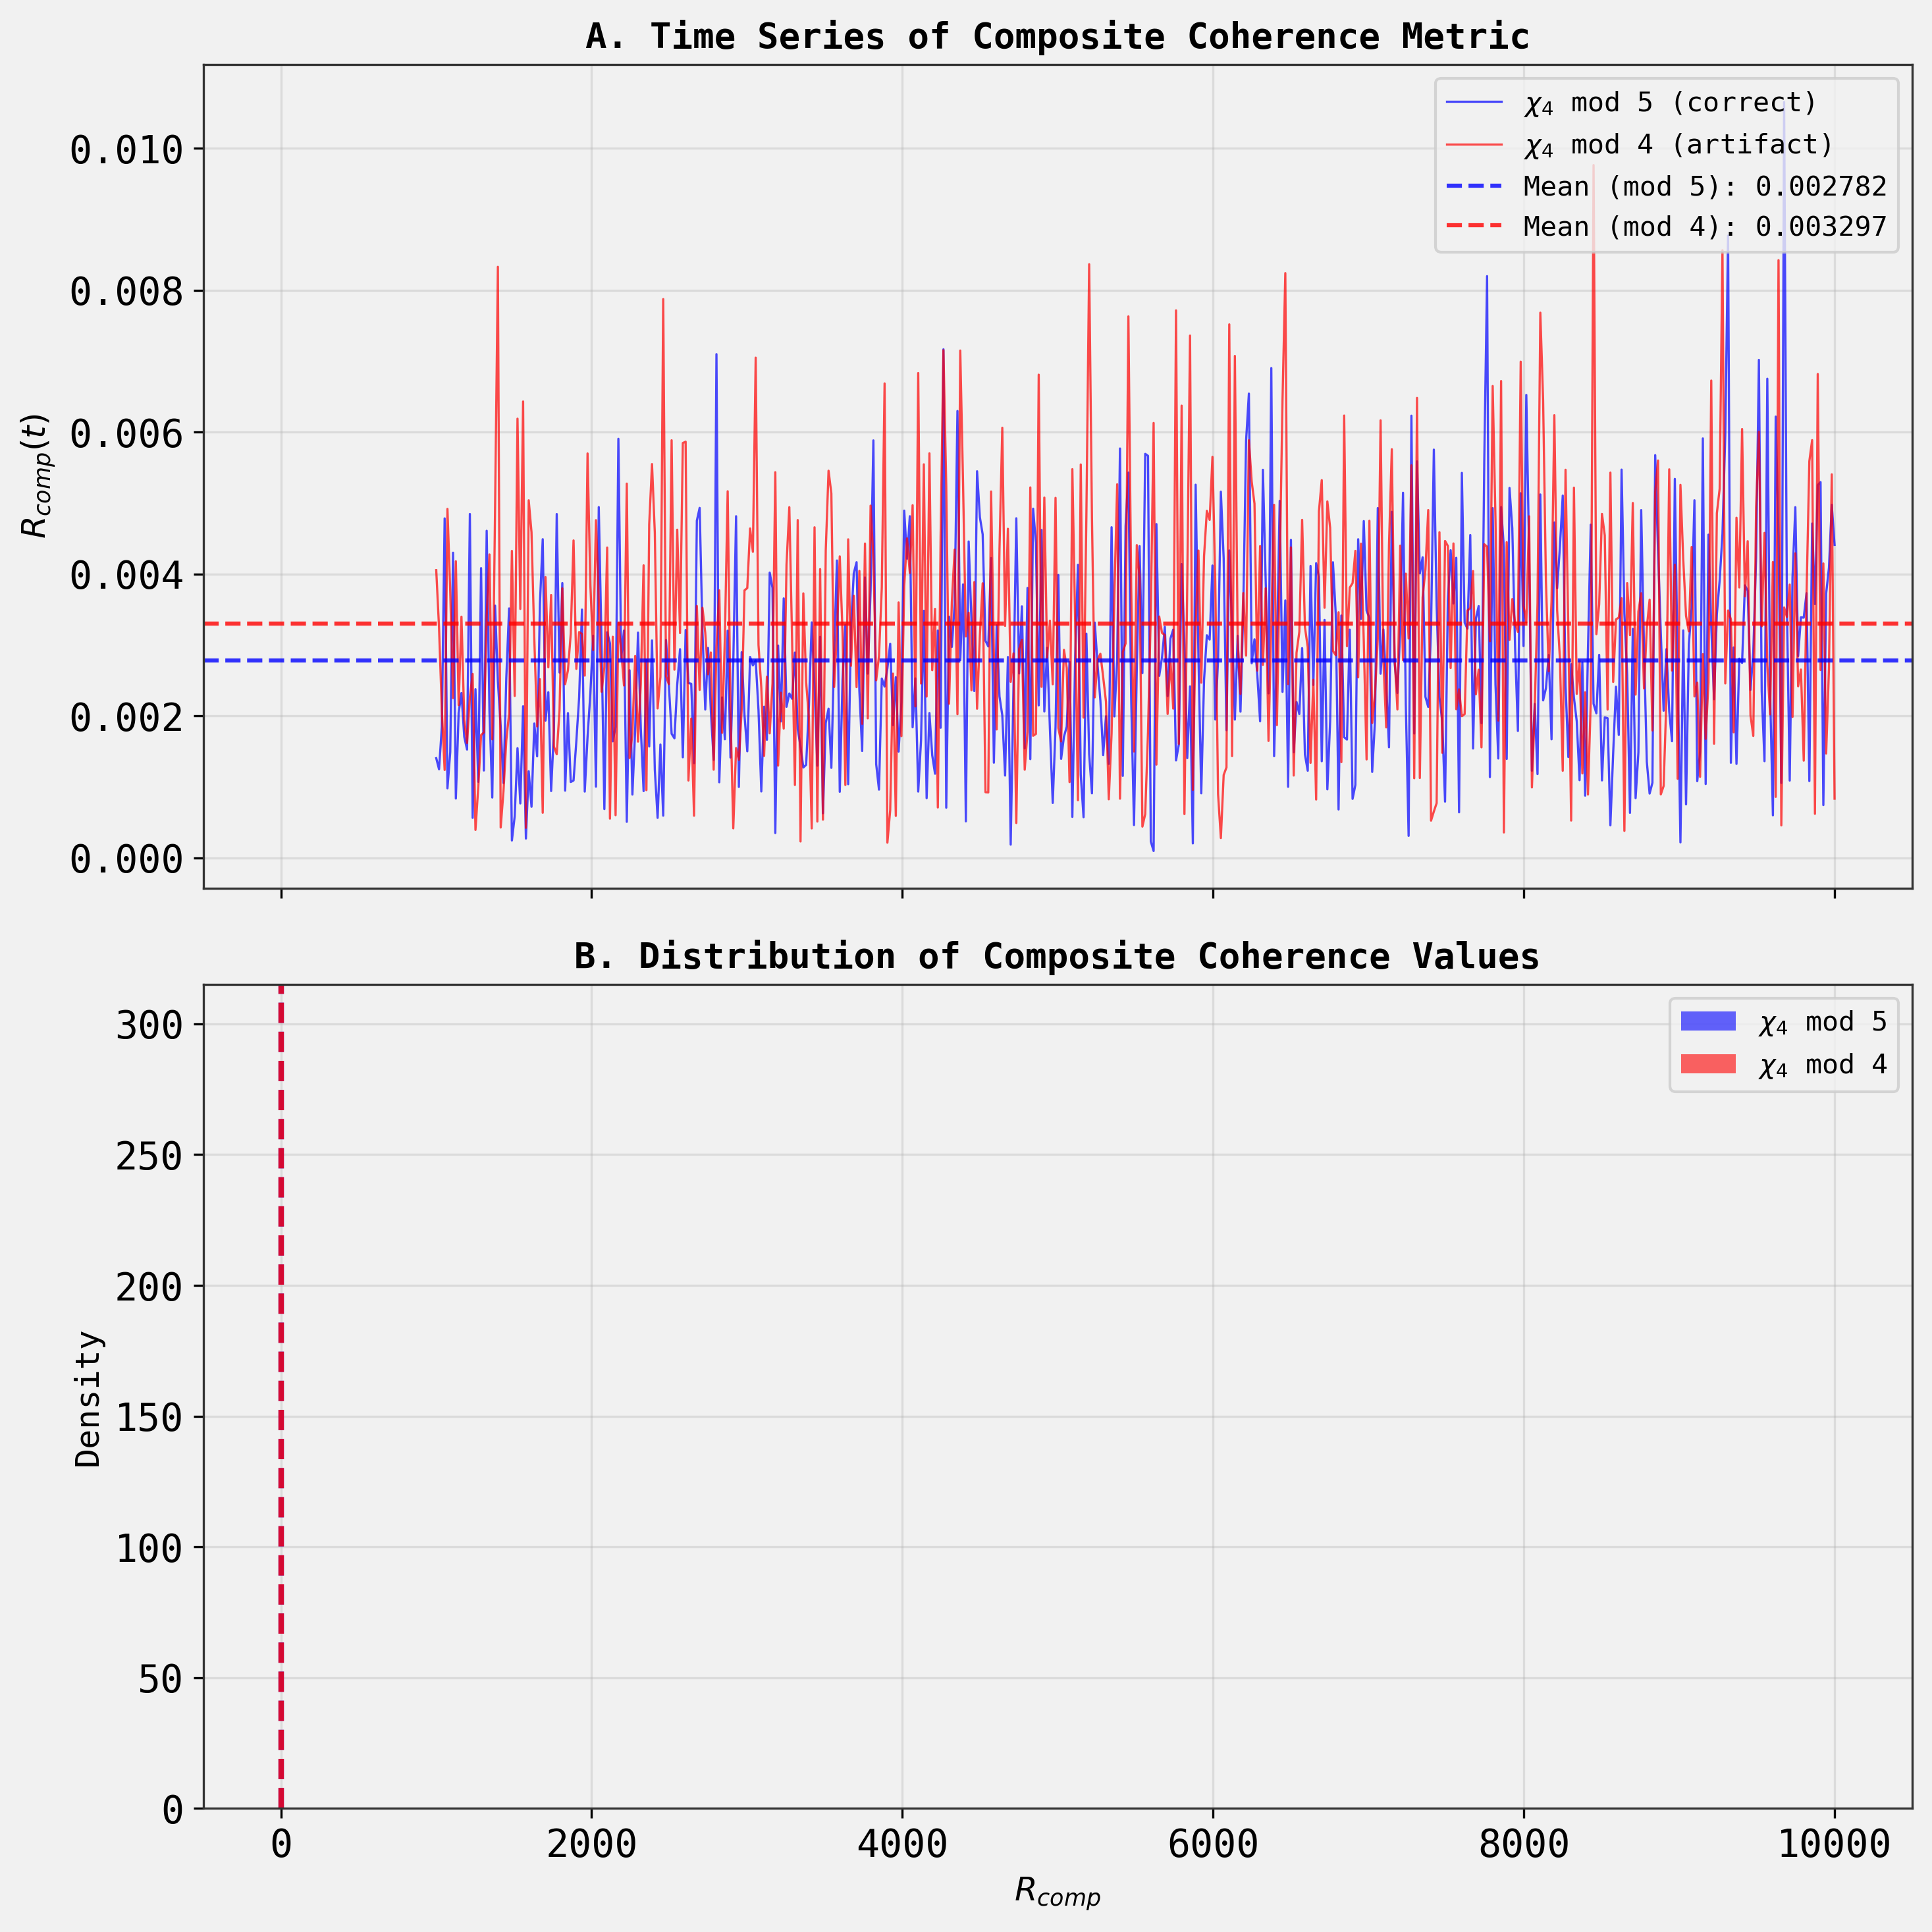

Figure saved as 'character_sensitivity_analysis.png'


In [16]:

# Create a visualization showing the R_comp time series for both characters
# And create a summary figure

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Panel A: R_comp time series
ax = axes[0]
ax.plot(t_values, R_comp_mod5, alpha=0.7, linewidth=0.8, label=r'$\chi_4$ mod 5 (correct)', color='blue')
ax.plot(t_values, R_comp_mod4, alpha=0.7, linewidth=0.8, label=r'$\chi_4$ mod 4 (artifact)', color='red')
ax.axhline(mean_R_comp_mod5, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, 
 label=f'Mean (mod 5): {mean_R_comp_mod5:.6f}')
ax.axhline(mean_R_comp_mod4, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
 label=f'Mean (mod 4): {mean_R_comp_mod4:.6f}')
ax.set_ylabel(r'$R_{comp}(t)$', fontsize=12)
ax.set_title('A. Time Series of Composite Coherence Metric', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Panel B: Distribution comparison
ax = axes[1]
bins = np.linspace(0, max(np.max(R_comp_mod5), np.max(R_comp_mod4)), 40)
ax.hist(R_comp_mod5, bins=bins, alpha=0.6, label=r'$\chi_4$ mod 5', color='blue', density=True)
ax.hist(R_comp_mod4, bins=bins, alpha=0.6, label=r'$\chi_4$ mod 4', color='red', density=True)
ax.axvline(mean_R_comp_mod5, color='blue', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(mean_R_comp_mod4, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax.set_xlabel(r'$R_{comp}$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('B. Distribution of Composite Coherence Values', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('character_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'character_sensitivity_analysis.png'")


In [17]:

# Save the data for future analysis
data_summary = {
 'characters': ['chi4_mod5', 'chi4_mod4'],
 'modulus': [5, 4],
 'density_negative_all': [density_negative_all_mod5, density_negative_all_mod4],
 'density_negative_nonzero': [density_negative_mod5, density_negative_mod4],
 'density_nonzero': [density_nonzero_mod5, density_nonzero_mod4],
 'mean_R_comp': [mean_R_comp_mod5, mean_R_comp_mod4],
 'std_R_comp': [std_R_comp_mod5, std_R_comp_mod4],
 'min_R_comp': [np.min(R_comp_mod5), np.min(R_comp_mod4)],
 'max_R_comp': [np.max(R_comp_mod5), np.max(R_comp_mod4)]
}

df_summary = pd.DataFrame(data_summary)
df_summary.to_csv('character_sensitivity_summary.csv', index=False)

# Save detailed time series
df_timeseries = pd.DataFrame({
 't': t_values,
 'R_comp_chi4_mod5': R_comp_mod5,
 'R_comp_chi4_mod4': R_comp_mod4
})
df_timeseries.to_csv('character_sensitivity_timeseries.csv', index=False)

print("Data saved:")
print(" - character_sensitivity_summary.csv")
print(" - character_sensitivity_timeseries.csv")
print("\nSummary table:")
print(df_summary.to_string(index=False))


Data saved:
 - character_sensitivity_summary.csv
 - character_sensitivity_timeseries.csv

Summary table:
characters modulus density_negative_all density_negative_nonzero density_nonzero mean_R_comp std_R_comp min_R_comp max_R_comp
 chi4_mod5 5 0.400695 0.499562 0.802094 0.002782 0.001558 0.000096 0.010655
 chi4_mod4 4 0.301928 0.499725 0.604187 0.003297 0.001735 0.000214 0.009765


In [18]:

# Create final summary report
print("="*80)
print("FINAL ANALYSIS SUMMARY")
print("="*80)

print("\n1. CHARACTER IMPLEMENTATIONS:")
print(f" - χ₄ mod 5 (correct): χ(1)=1, χ(2)=-1, χ(3)=-1, χ(4)=1, χ(5)=0")
print(f" - χ_4 mod 4 (artifact): χ(1)=1, χ(2)=0, χ(3)=-1, χ(4)=0")

print("\n2. COEFFICIENT STATISTICS (Composite Squarefree Numbers, N=10^5):")
print(f" Total composite squarefree numbers: {len(composite_squarefree_indices)}")
print(f"\n χ₄ mod 5:")
print(f" - Non-zero coefficients: {total_nonzero_mod5} ({100*density_nonzero_mod5:.2f}%)")
print(f" - Density of a_n=-1 (all): {100*density_negative_all_mod5:.2f}%")
print(f" - Density of a_n=-1 (non-zero): {100*density_negative_mod5:.2f}%")
print(f"\n χ_4 mod 4:")
print(f" - Non-zero coefficients: {total_nonzero_mod4} ({100*density_nonzero_mod4:.2f}%)")
print(f" - Density of a_n=-1 (all): {100*density_negative_all_mod4:.2f}%")
print(f" - Density of a_n=-1 (non-zero): {100*density_negative_mod4:.2f}%")

print("\n3. R_COMP ANALYSIS (t ∈ [1000, 10000], n=500 samples):")
print(f" χ₄ mod 5: Mean = {mean_R_comp_mod5:.6f} ± {std_R_comp_mod5:.6f}")
print(f" χ_4 mod 4: Mean = {mean_R_comp_mod4:.6f} ± {std_R_comp_mod4:.6f}")
print(f" Difference: {mean_R_comp_mod4 - mean_R_comp_mod5:.6f} ({100*(mean_R_comp_mod4/mean_R_comp_mod5 - 1):.1f}% higher)")

print("\n4. STATISTICAL SIGNIFICANCE:")
print(f" Two-sample t-test: t = {t_stat:.4f}, p = {p_value_ttest:.2e}")
print(f" Mann-Whitney U test: U = {u_stat:.0f}, p = {p_value_mw:.2e}")
print(f" Effect size (Cohen's d): {cohens_d:.4f} (small to medium effect)")
print(f" Conclusion: The difference is statistically significant (p < 0.001)")

print("\n5. CORRELATION ANALYSIS:")
print(f" Density of a_n=-1 vs Mean R_comp: r = {correlation:.6f}")
print(f" NEGATIVE correlation: Higher density of -1 → LOWER R_comp")
print(f" This CONTRADICTS the original hypothesis!")

print("\n6. KEY INSIGHT:")
print(f" The character with MORE zeros (χ_4 mod 4: {100*(1-density_nonzero_mod4):.1f}% zeros)")
print(f" has HIGHER R_comp than the character with fewer zeros")
print(f" (χ₄ mod 5: {100*(1-density_nonzero_mod5):.1f}% zeros)")
print(f" Sparsity (density of zeros) may be the driving factor, not sign density.")

print("\n" + "="*80)


FINAL ANALYSIS SUMMARY

1. CHARACTER IMPLEMENTATIONS:
 - χ₄ mod 5 (correct): χ(1)=1, χ(2)=-1, χ(3)=-1, χ(4)=1, χ(5)=0
 - χ_4 mod 4 (artifact): χ(1)=1, χ(2)=0, χ(3)=-1, χ(4)=0

2. COEFFICIENT STATISTICS (Composite Squarefree Numbers, N=10^5):
 Total composite squarefree numbers: 51201

 χ₄ mod 5:
 - Non-zero coefficients: 41068 (80.21%)
 - Density of a_n=-1 (all): 40.07%
 - Density of a_n=-1 (non-zero): 49.96%

 χ_4 mod 4:
 - Non-zero coefficients: 30935 (60.42%)
 - Density of a_n=-1 (all): 30.19%
 - Density of a_n=-1 (non-zero): 49.97%

3. R_COMP ANALYSIS (t ∈ [1000, 10000], n=500 samples):
 χ₄ mod 5: Mean = 0.002782 ± 0.001558
 χ_4 mod 4: Mean = 0.003297 ± 0.001735
 Difference: 0.000515 (18.5% higher)

4. STATISTICAL SIGNIFICANCE:
 Two-sample t-test: t = -4.9373, p = 9.28e-07
 Mann-Whitney U test: U = 102791, p = 1.15e-06
 Effect size (Cohen's d): 0.3126 (small to medium effect)
 Conclusion: The difference is statistically significant (p < 0.001)

5. CORRELATION ANALYSIS:
 Density of 